## K-Means Cluster Analysis of Fidelity Fund Returns 
### University of Virginia
### DS 7200: Distributed Computing
### Last Updated: August 20, 2023

## Instructions

In this assignment, you will conduct a k-means cluster analysis on a set of Fidelity mutual funds.  
This helps to group similar funds based on their performance (as opposed to their description, which is typical).  
The outline below will walk you through the required steps.  

This assignment is worth a total of **10 POINTS.**

## Data Details 

The file *fido_returns_funds_on_rows.csv* is the processed data for k-means. Additional details about this file: 
- Each row represents a mutual fund  
- Each column represents a trading day (these are used as features)  
- Each value represents the daily percentage change in price between the current trading day and previous trading day

### Load Modules and Read Data into Spark DataFrame

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler

# Loads data
df = spark.read.csv("fido_returns_funds_on_rows.csv", header=True, inferSchema=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/08 11:30:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/08 11:30:29 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
                                                                                

**(VALUE: 2 POINTS) Assemble the Features into a column. 
Show the first five rows of data ONLY for the features column.
(this should make things easier to read)**

In [2]:
feats = df.columns      
assembler = VectorAssembler(inputCols=feats, outputCol="features")
dataset=assembler.transform(df).select("features") # ONLY for the features column
dataset.show(5) # Show the first five rows of data 

26/10/08 11:30:37 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 2:>                                                          (0 + 1) / 1]

+--------------------+
|            features|
+--------------------+
|[0.0,0.0,-0.01040...|
|[0.0,0.0,-0.01051...|
|[0.0,0.0,-0.01076...|
|[0.0,8.26105E-4,-...|
|[0.0,8.2815740000...|
+--------------------+
only showing top 5 rows


**(VALUE: 1 POINT) Set up the k-means model and train the model**  
Use parameters: 
- 3 clusters
- maximum of 10 iterations 
- seed=314

In [3]:
kmeans = KMeans().setK(3).setSeed(314).setMaxIter(10)
model = kmeans.fit(dataset)

26/10/08 11:30:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/10/08 11:30:51 WARN DAGScheduler: Broadcasting large task binary with size 1018.8 KiB
                                                                                

**(VALUE: 2 POINTS) Compute and Print the Silhouette Score**  

In [4]:
predictions = model.transform(dataset)

# Evaluate clustering by computing Silhouette score
evaluator = ClusteringEvaluator()

silhouette = evaluator.evaluate(predictions)
print("Silhouette with squared euclidean distance = " + str(silhouette))

[Stage 29:=============================>                            (1 + 1) / 2]

Silhouette with squared euclidean distance = 0.5968153391202368


**(VALUE: 2 POINTS) Define a function `kmeans_range()` that does the following:**
- takes an integer representing the lower bound for k
- takes an integer representing the upper bound for k
- take a Spark DataFrame containing training data
- fit K-means with k ranging from lower bound to upper bound, inclusive  
- the other parameters should be the same as earlier 
- for each k, compute the silhouette score
- return a pandas dataframe with columns containing k, silhouette score (each row holds the score for given k)

In [5]:
import pandas as pd

def kmeans_range(lower, upper, data): # int lower, int upper, Spark DF inputs
    evaluator = ClusteringEvaluator()
    
    results = [] 

    for k in range(lower, upper + 1): 
        kmeans = KMeans().setK(k).setSeed(314).setMaxIter(10)
        model = kmeans.fit(data)
        predictions = model.transform(data)

        silhouette = evaluator.evaluate(predictions)
        results.append((k, silhouette))

    return pd.DataFrame(results, columns=["k", "silhouette"])

**(VALUE: 1 POINT) Call `kmeans_range` to compute K-means with clusters ranging from 2 to 10 inclusive, printing the resulting dataframe.**

In [6]:
score = kmeans_range(2, 10, dataset)

print(score)

26/10/08 11:31:02 WARN DAGScheduler: Broadcasting large task binary with size 1005.3 KiB
26/10/08 11:31:11 WARN DAGScheduler: Broadcasting large task binary with size 1018.8 KiB
26/10/08 11:31:19 WARN DAGScheduler: Broadcasting large task binary with size 1032.4 KiB
26/10/08 11:31:26 WARN DAGScheduler: Broadcasting large task binary with size 1045.9 KiB
26/10/08 11:31:34 WARN DAGScheduler: Broadcasting large task binary with size 1059.4 KiB
26/10/08 11:31:41 WARN DAGScheduler: Broadcasting large task binary with size 1073.0 KiB
26/10/08 11:31:49 WARN DAGScheduler: Broadcasting large task binary with size 1086.5 KiB
26/10/08 11:31:56 WARN DAGScheduler: Broadcasting large task binary with size 1100.1 KiB
26/10/08 11:32:01 WARN DAGScheduler: Broadcasting large task binary with size 1113.6 KiB
                                                                                

    k  silhouette
0   2    0.602396
1   3    0.596815
2   4    0.430189
3   5    0.496837
4   6    0.461175
5   7    0.484657
6   8    0.365602
7   9    0.313600
8  10    0.354400


**(VALUE: 1 POINT) Produce a plot with cluster numbers k on the x-axis, sihouette scores on the y-axis**

In [7]:
import matplotlib.pyplot as plt

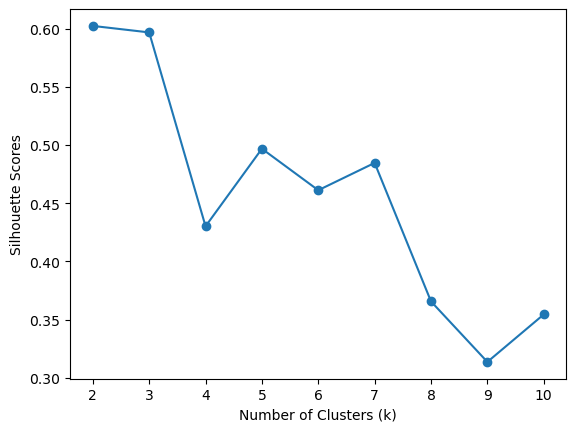

In [8]:
plt.plot(score["k"], score["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Scores")
plt.show()

**(VALUE: 1 POINT) Based on how the silhouette score is calculated, what is its time complexity? (e.g., O(log n))**  
You can find the definition of the silhouette score in the lecture notes, for example. 

O(n^2)

For each point n, we compute A, which is defined as "the mean distance of each point to its neighbors within its cluster", and B, "the mean distance of each point to its next-closest cluster". Basically we are calculating n * (n-1) times here since calculating these values requires a value from every point, which is O(n). Doing this for all n points, leads us to the aforementioned O(n^2) conclusion. 